In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pyarrow
import pickle
import json
import pwlf
import re
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
import utils.conduits as conduits
importlib.reload(conduits)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)
import utils.spring as spring
importlib.reload(spring)
from utils.spring import outlet_flow, write_outlet_flow, calculate_recession_coefficients
from scripts.openkarst.run_openkarst import load_network_data

In [3]:

sim_list =['anastomotic_simple_low_slope',
'anastomotic_simple_clean',
'branching_straight_network',
'pykasso_n58_low_slope',
'pykasso_n58',
'single_conduit_vert_tort',
'slope_0008',
'straight_conduit_n62',
'anastomotic_simple_low_slope/double_gaussian',
'anastomotic_simple_clean/double_gaussian',
'branching_straight_network/double_gaussian',
'pykasso_n58_low_slope/double_gaussian',
'pykasso_n58/double_gaussian',
'single_conduit_vert_tort/double_gaussian',
'slope_0008/double_gaussian',
'straight_conduit_n62/double_gaussian'
]
Qs = {}
networks = {}
for network_name in sim_list:
    network_output = f'conduit_geometry_test/output/{network_name}'
    run_dirs = os.listdir(network_output)
    Qs[network_name] = {}
    networks[network_name] = {}
    for run in run_dirs:
        if run not in ['partitioned', 'diffuse', 'point']:
            continue
        input_data = load_pickle( f'{network_output}/{run}/input_data.pkl')
        network = utils.openkarst_network.OpenKarstNetwork(nodes = input_data['nodes'], edges = input_data['edges'])
        network.load_cave_data()
        network.extract_boundary_nodes()
        networks[network_name][run] = network
        spring_path = f'{network_output}/{run}/spring.csv'
        try: 
            spring_Q = pd.read_csv(spring_path)
            Qs[network_name][run] = spring_Q
        except FileNotFoundError:
            try:
                results = np.load(f'{network_output}/{run}/results_arrays.npz')
            except FileNotFoundError:
                print(f'skipping {network_output}/{run}')
                continue
            Q = results['Q']
            y = results['y']
            t = results['t']
            input_data = load_pickle( f'{network_output}/{run}/input_data.pkl')
            spring_Q = outlet_flow(network, Q)
            temp = pd.DataFrame()
            for node, flow in spring_Q.items():
                temp['inflow'] = flow
                temp['node'] = node
                temp['time'] = t
            Qs[network_name][run] = temp
            temp.to_csv(spring_path, index = False)
            continue


skipping conduit_geometry_test/output/anastomotic_simple_low_slope/diffuse
skipping conduit_geometry_test/output/anastomotic_simple_clean/diffuse
skipping conduit_geometry_test/output/single_conduit_vert_tort/diffuse
skipping conduit_geometry_test/output/anastomotic_simple_low_slope/double_gaussian/diffuse
skipping conduit_geometry_test/output/anastomotic_simple_clean/double_gaussian/diffuse
skipping conduit_geometry_test/output/branching_straight_network/double_gaussian/diffuse
skipping conduit_geometry_test/output/pykasso_n58_low_slope/double_gaussian/diffuse
skipping conduit_geometry_test/output/pykasso_n58/double_gaussian/diffuse
skipping conduit_geometry_test/output/single_conduit_vert_tort/double_gaussian/diffuse
skipping conduit_geometry_test/output/slope_0008/double_gaussian/diffuse
skipping conduit_geometry_test/output/straight_conduit_n62/double_gaussian/diffuse


In [4]:
r = pd.read_csv('conduit_geometry_test/input_data/recharge_m_s/gaussian_pulse.csv')
test = Qs['anastomotic_simple_clean/double_gaussian']['partitioned']
t1 = test['time']
Q1 = test['inflow']
r_interp = np.interp(t1, r['time'], r['R_l [V/T]'] + r['R_h [V/T]'])

In [5]:
conditions = lambda name : ('double_gaussian' not in name) or ('pykasso_n58_low_slope' in name) or ('single_conduit_vert_tort' in name) or ('anastomotic_simple_low_slope' in name)

In [6]:
color_dict = {
   'straight_conduit_n62/double_gaussian': "#0000ff",
   'pykasso_n58/double_gaussian': "#9d02d7",
   'slope_0008/double_gaussian': "#ea5f94",
     "branching_straight_network/double_gaussian": "#ffb14e",  
     'anastomotic_simple_clean/double_gaussian': "#ffd700",
}
label_dict = {'branching_straight_network/double_gaussian' : 'Branching Straight Network', 
              'pykasso_n58_low_slope/double_gaussian' : 'Pykasso Low Slope', 
              'pykasso_n58/double_gaussian' : 'Tortuous Single Conduit', 
              'straight_conduit_n62/double_gaussian' : 'Single Conduit', 
               'anastomotic_simple_clean/double_gaussian' : 'Anastomotic', 
               'single_conduit_vert_tort/double_gaussian' : 'Vertically Tortuous', 
               'anastomotic_low_slope/double_gaussian' : 'Anastomotic Low Slope',
               'slope_0008/double_gaussian' : 'Low Slope Single Conduit'
}

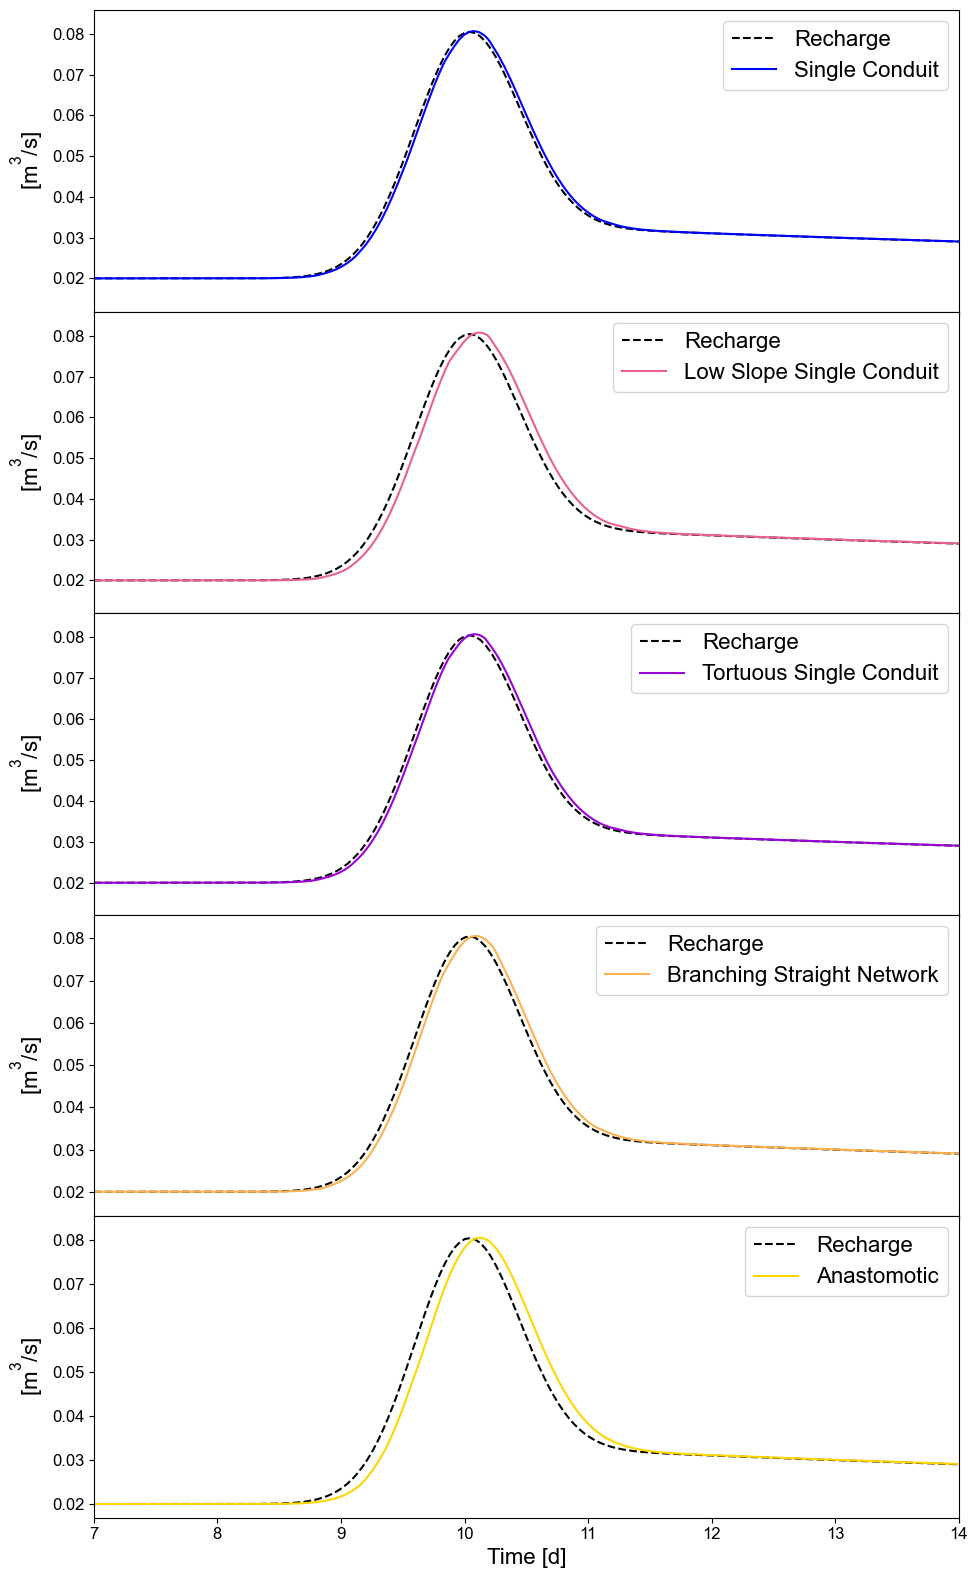

In [12]:
fig, ax = plt.subplots(5,1, figsize = (10,16), sharex = True, gridspec_kw={'hspace': 0,})
i = 0 
for run, Q_dict in Qs.items():
    if conditions(run):
        continue
    for r_dist, Q_df in Q_dict.items():
        if r_dist in ['diffuse', 'diffuse_only', 'point_only']:
            continue
        sns.lineplot(x = t1/86400, y = r_interp, label = 'Recharge', color = 'black', linestyle = '--', ax = ax[4-i])

        sns.lineplot(data = Q_df, x = Q_df['time']/86400, y = 'inflow', label = label_dict[f'{run}'], ax = ax[4-i], color = color_dict[run])
        ax[i].set_ylabel(r'[m$^3$/s]')
    i+=1
plt.xlabel("Time [d]")
plt.xlim(7, 14)
plt.tight_layout()


In [13]:
baseflow = 0.02 #m3/s

anastomotic_simple_clean/double_gaussian
704


NameError: name 'baseflow' is not defined

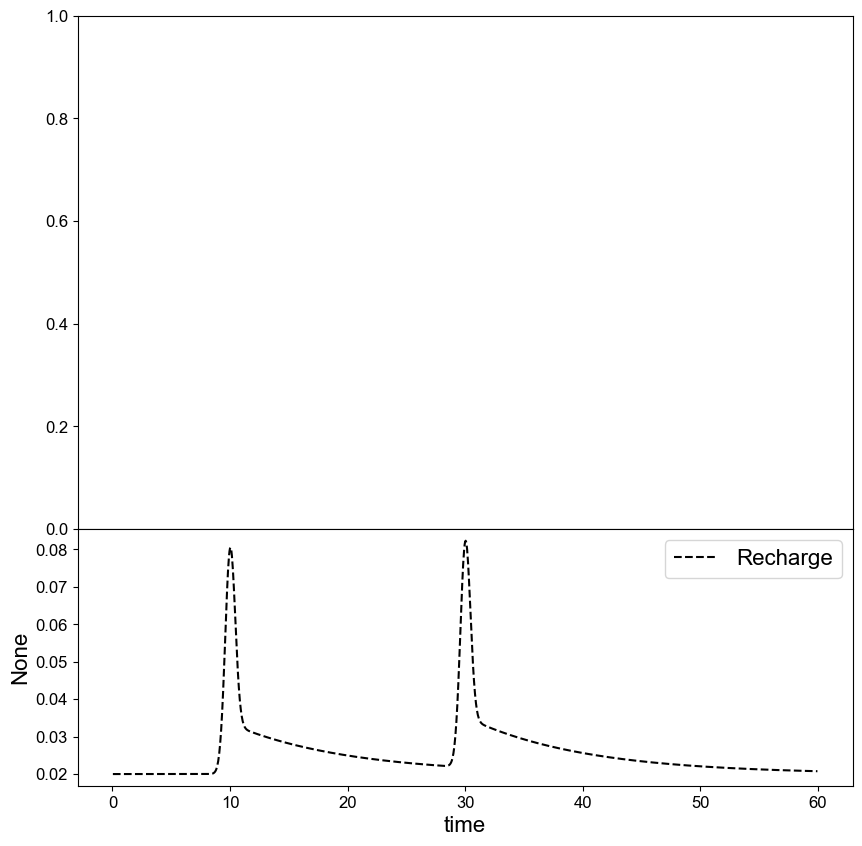

In [10]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14            # main text size
plt.rcParams['axes.labelsize'] = 16       # axis labels
plt.rcParams['axes.titlesize'] = 18       # title
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'      # Roman style
plt.rcParams['mathtext.it'] = 'Arial:italic' # Italic style
plt.rcParams['mathtext.bf'] = 'Arial:bold'   # Bold style



r = pd.read_csv('conduit_geometry_test/input_data/recharge_m_s/double_gaussian.csv')
fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True, gridspec_kw={'hspace': 0, 'height_ratios' : [1, 0.5]}, )
residual_df = pd.DataFrame(columns=['network_name', 'positive_peak_time', 'positive_peak_value', 'relative_positive_peak_value', 'negative_peak_time', 'negative_peak_value', 'relative_negative_peak_value', 'pulse_width', 'net S', 'net_S_V', 'peak_delay'])
sns.lineplot(x=r['time']/86400, y=r['R_l [V/T]'] + r['R_h [V/T]'], label='Recharge', color = 'black', linestyle = '--', ax = ax[1])
for run, Q_dict in Qs.items():
    if conditions(run):
        continue
    print(run)
    for r_dist, Q_df in Q_dict.items():
        if r_dist in ['diffuse', 'diffuse_only', 'point_only']:
            continue
        temp_network = networks[run][r_dist]
        network_V = temp_network.calculate_network_volume()
        r_interp = np.interp(Q_df['time'], r['time'], r['R_l [V/T]'] + r['R_h [V/T]'])
        residual = (r_interp - Q_df['inflow']) #ignore initial noise
        t_residual = Q_df['time']
        t_threshold = 2 * 86400  # 2 days
        analysis_mask = (t_residual > t_threshold) & (t_residual < (t_threshold + 20 * 86400))
        Q_spring = Q_df['inflow'][analysis_mask]
        residual_analysis = residual[analysis_mask]
        t_residual_analysis = t_residual[analysis_mask]
        r_interp_analysis = r_interp[analysis_mask]
        peak_delay = t_residual_analysis.values[Q_spring.argmax()] - t_residual_analysis.values[r_interp_analysis.argmax()]

        threshold = 0.1* np.max(np.abs(residual_analysis))
        mask = np.abs(residual_analysis) > threshold
        width = t_residual_analysis[mask].values[-1] - t_residual_analysis[mask].values[0]
        total_S = np.trapezoid(residual_analysis[mask], x= t_residual_analysis[mask])
        net_S_V = total_S / network_V
        positive_peak_time = t_residual_analysis[mask].values[residual_analysis[mask].argmax()]
        print(residual_analysis[mask].argmax())
        positive_peak_value = residual_analysis[mask].max()
        relative_positive_peak_value = positive_peak_value/baseflow
        negative_peak_time = t_residual_analysis[mask].values[residual_analysis[mask].argmin()]
        negative_peak_value = residual_analysis[mask].min()
        relative_negative_peak_value = negative_peak_value/baseflow
        residual_df.loc[len(residual_df)] =[f'{run}_{r_dist}', positive_peak_time/86400, positive_peak_value, relative_positive_peak_value, negative_peak_time/86400, negative_peak_value, relative_negative_peak_value, width/86400, total_S, net_S_V, peak_delay/86400]
        sns.lineplot(x=t_residual/86400, y=residual/baseflow, label=label_dict[f'{run}'], linestyle = '--', ax = ax[0], color = color_dict[run])

residual_df['peak to peak time'] = residual_df['negative_peak_time'] - residual_df['positive_peak_time']
residual_df['peak to peak value'] = residual_df['positive_peak_value'] - residual_df['negative_peak_value']
residual_df['relative peak to peak value'] = residual_df['relative_positive_peak_value'] - residual_df['relative_negative_peak_value']
residual_df['peak asymmetry'] = (residual_df['positive_peak_value'] + residual_df['negative_peak_value'])
residual_df['relative peak asymmetry'] = (residual_df['relative_positive_peak_value'] + residual_df['relative_negative_peak_value'])
residual_df['base_thruput'] = residual_df.pulse_width * 86400 * baseflow
residual_df['relative_net_S'] = residual_df['net S'] / residual_df['base_thruput']
ax[0].legend(loc = 'upper right')
ax[0].set_xlabel('Time (days)')
ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel(r'$\dot{S}$* [-]')
ax[1].set_ylabel(r'[m$^3$/s]')
# ax[0].set_title("Transient Storage")
plt.xlim(7,14)
ax[0].set_ylim(-0.4, 0.4)


(-0.15, 0.15)

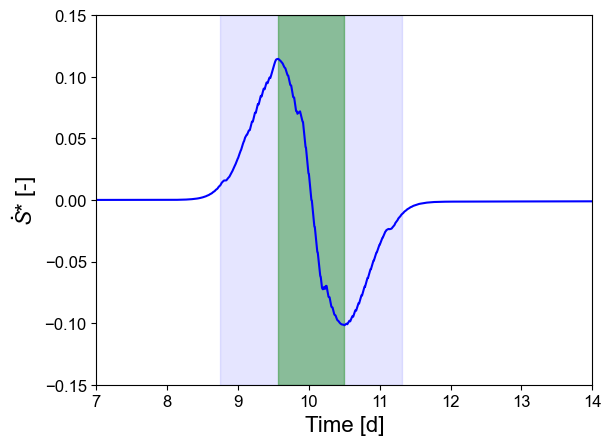

In [294]:
sns.lineplot(x = t_residual_analysis/86400, y = residual_analysis/baseflow, color = color_dict[run])
plt.axvspan(
    t_residual_analysis[mask].values[0]/86400,
    t_residual_analysis[mask].values[-1]/86400,
    color='blue',
    alpha=0.1,
    label = 'Pulse duration'
)
# peak-to-peak delay region
plt.axvspan(
    positive_peak_time/86400,
    negative_peak_time/86400,
    color='green',
    alpha=0.4,
    label = 'Peak-to-peak duration'
)

# total pulse width region

plt.xlim(7, 14)
plt.xlabel("Time [d]")
plt.ylabel(r"$\dot{S}$* [-]")
plt.ylim(-0.15, 0.15)


In [22]:
residual_df

,network_name,positive_peak_time,positive_peak_value,relative_positive_peak_value,negative_peak_time,negative_peak_value,relative_negative_peak_value,pulse_width,net S,net_S_V,peak_delay,peak to peak time,peak to peak value,relative peak to peak value,peak asymmetry,relative peak asymmetry,base_thruput,relative_net_S
0,anastomotic_simple_clean/double_gaussian_parti...,9.650466,0.007375,0.368760,10.541669,-0.006430,-0.321476,2.502310,49.768249,0.006847,0.081019,0.891204,0.013805,0.690236,0.000946,0.047284,4323.990863,0.011510
1,branching_straight_network/double_gaussian_par...,9.556716,0.003487,0.174354,10.500000,-0.002998,-0.149924,2.572917,28.750990,0.004520,0.050925,0.943284,0.006486,0.324278,0.000489,0.024430,4445.999871,0.006467
2,pykasso_n58/double_gaussian_partitioned,9.622686,0.002678,0.133895,10.500004,-0.002492,-0.124588,2.591434,10.296529,0.005627,0.041667,0.877318,0.005170,0.258483,0.000186,0.009308,4477.997922,0.002299
3,slope_0008/double_gaussian_partitioned,9.645837,0.004951,0.247559,10.500002,-0.004509,-0.225429,2.589120,25.178738,0.013761,0.075233,0.854166,0.009460,0.472988,0.000443,0.022131,4473.999047,0.005628
4,straight_conduit_n62/double_gaussian_partitioned,9.564818,0.002289,0.114439,10.500002,-0.002036,-0.101777,2.572915,12.268898,0.006705,0.034724,0.935184,0.004324,0.216216,0.000253,0.012662,4445.996350,0.002760


In [24]:
residual_df[['network_name', 'pulse_width', 'relative_positive_peak_value', 'peak to peak time', 'peak to peak value', 'relative peak to peak value', 'relative peak asymmetry', 'relative_net_S', 'peak_delay']]

,network_name,pulse_width,relative_positive_peak_value,peak to peak time,peak to peak value,relative peak to peak value,relative peak asymmetry,relative_net_S,peak_delay
0,anastomotic_simple_clean/double_gaussian_parti...,2.502310,0.368760,0.891204,0.013805,0.690236,0.047284,0.011510,0.081019
1,branching_straight_network/double_gaussian_par...,2.572917,0.174354,0.943284,0.006486,0.324278,0.024430,0.006467,0.050925
2,pykasso_n58/double_gaussian_partitioned,2.591434,0.133895,0.877318,0.005170,0.258483,0.009308,0.002299,0.041667
3,slope_0008/double_gaussian_partitioned,2.589120,0.247559,0.854166,0.009460,0.472988,0.022131,0.005628,0.075233
4,straight_conduit_n62/double_gaussian_partitioned,2.572915,0.114439,0.935184,0.004324,0.216216,0.012662,0.002760,0.034724


In [7]:
analysis_df =pd.DataFrame(columns=['network_name', 'alpha_1', 'alpha_2',  't_alpha_1', 't_alpha_2',  'volume'])
for name, Q_dict in Qs.items():
    if conditions(name):
        continue
    for r_dist, Q_df in Q_dict.items():
        if r_dist in ['diffuse', 'diffuse_only', 'point_only']:
            continue
        try:
            Q_df = Q_df[(Q_df['time'] < 20*86400) & (Q_df['time'] > 2*86400)]
            alpha, t_alpha = calculate_recession_coefficients(Q_df['time'], Q_df['inflow'], n_coeffs=2)
            alpha *= -1
            volume = spring.calculate_volume(Q_df['time'], Q_df['inflow'])
            analysis_df.loc[len(analysis_df)] = {'network_name': label_dict[name], 'alpha_1': alpha[0], 'alpha_2': alpha[1], 't_alpha_1': t_alpha[0], 't_alpha_2': t_alpha[1], 'volume': volume}
        except Exception as e:
            print(f"Error processing {name}: {e}")
            continue

In [8]:
analysis_df['alpha_1_d'] = analysis_df['alpha_1'] * 86400
analysis_df['alpha_2_d'] = analysis_df['alpha_2'] * 86400

In [33]:
analysis_df

,network_name,alpha_1,alpha_2,t_alpha_1,t_alpha_2,volume,alpha_1_d,alpha_2_d
0,Anastomotic,0.000011,3.332484e-07,874600.183641,970684.390871,43382.104385,0.917554,0.028793
1,Branching Straight Network,0.000011,3.337612e-07,872000.173892,964286.246531,43384.264916,0.950787,0.028837
2,Tortuous Single Conduit,0.000011,3.330321e-07,871200.091509,963267.848901,43392.318195,0.955353,0.028774
3,Low Slope Single Conduit,0.000011,3.342261e-07,874100.258659,966222.400959,43396.025547,0.950813,0.028877
4,Single Conduit,0.000011,3.329253e-07,870600.242443,962638.269162,43390.356388,0.956225,0.028765


Text(0, 0.5, 'log Q [m$^3$/s]')

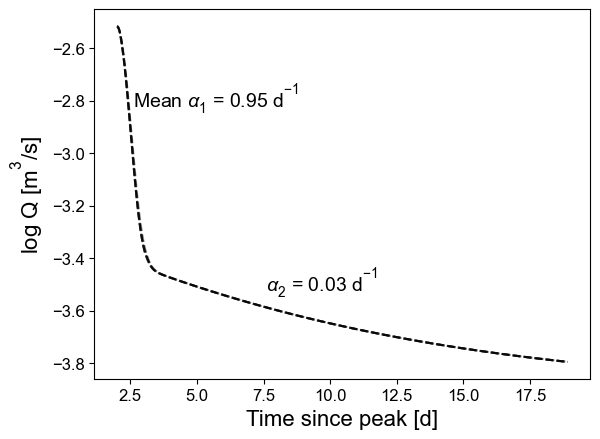

In [11]:
for name, Q_dict in Qs.items():
    if conditions(name):
        continue
    for r_dist, Q_df in Q_dict.items():
        if r_dist in ['diffuse', 'diffuse_only', 'point_only']:
            continue
        Q_df = Q_df[(Q_df['time'] < 27*86400) & (Q_df['time'] > 2*86400)]
        peak_idx, peak_time, peak_flow = spring.find_peak(Q_df['time'], Q_df['inflow'])
        logQ = np.log(Q_df['inflow'][peak_idx:])
        sns.lineplot(x=((Q_df['time'][peak_idx:] - peak_time)/86400), y=logQ, alpha = 0.5, linestyle = '--', color = 'black')


x_text = 2.6
y_text = logQ.iloc[(len(logQ)//2)] + .8

plt.text(
    x=x_text,
    y=y_text,
    s=rf"Mean $\alpha_1$ = {analysis_df['alpha_1'].mean() * 86400:.2f} d$^{{-1}}$",
    ha='left',
    va='bottom'
)
plt.text(
    x=x_text + 5,
    y=y_text - .7,
    s=rf"$\alpha_2$ = {analysis_df['alpha_2'].mean() * 86400:.2f} d$^{{-1}}$",
    ha='left',
    va='bottom'
)

plt.xlabel('Time since peak [d]')
plt.ylabel(r'log Q [m$^3$/s]')
# plt.title("Recession Limb Analysis")